# 10. Hierarchical Models, Partial Pooling, and Grouped Data

Statistical inference often breaks when we pretend that grouped data are either completely identical or completely unrelated. Hierarchical models give us a disciplined middle ground: estimate group-specific effects while borrowing strength across the full sample.


## Learning Objectives

After working through this lecture, you should be able to:

- explain the difference between complete pooling, no pooling, and partial pooling,
- write down a random-intercept hierarchical model for grouped operational data,
- understand why small groups should be shrunk more aggressively than large groups,
- fit a mixed-effects model and interpret the estimated group variance,
- connect partial pooling to a real resource-allocation decision.


In [1]:
# Load the libraries and notebook settings used in the examples below.
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", None)

sns.set_theme(style="whitegrid", context="notebook")

COLORS = {
    "truth": "#0f172a",
    "no_pool": "#c2410c",
    "partial": "#15803d",
    "accent": "#1d4ed8",
}


## 1. Why Grouped Data Need Special Treatment

Suppose a platform team wants to compare software support pods after major releases. Each pod resolves a different number of incidents, and the releases differ in severity, congestion, and customer mix.

A naive analyst has two easy but flawed options:

- **Complete pooling:** act as if all pods are identical and estimate one common intercept.
- **No pooling:** estimate each pod separately and take those raw estimates at face value.

The first strategy suppresses real cross-pod differences. The second strategy overreacts to noise, especially when some pods have only a handful of observed releases.

Hierarchical modeling solves this by treating pod effects as related draws from a common distribution. That is the statistical version of a sensible managerial principle: small-sample judgments should be more cautious than large-sample judgments.


## 2. Statistical Setup

Let $y_{ij}$ denote stabilization hours for release $i$ handled by pod $j$. We use the random-intercept model

$$
y_{ij} = x_{ij}^{\top}\beta + u_j + \varepsilon_{ij},
$$

where

$$
u_j \sim \mathcal{N}(0, \tau^2), \qquad \varepsilon_{ij} \sim \mathcal{N}(0, \sigma^2).
$$

Here:

- $x_{ij}^{\top}\beta$ captures the shared effect of release-level covariates,
- $u_j$ captures pod-specific deviation from the global baseline,
- $\tau^2$ is between-pod variation,
- $\sigma^2$ is within-pod noise.

If we first remove the pooled fixed-effect prediction and compute the pod-level adjusted average residual

$$
\bar{r}_j = \frac{1}{n_j}\sum_{i=1}^{n_j}\left(y_{ij} - x_{ij}^{\top}\hat{\beta}_{\text{pooled}}\right),
$$

then the empirical-Bayes partial-pooling estimate has the form

$$
\hat{u}_j^{\text{partial}} = w_j \bar{r}_j,
\qquad
w_j = \frac{\hat{\tau}^2}{\hat{\tau}^2 + \hat{\sigma}^2 / n_j}.
$$

This formula explains the whole idea:

- when $n_j$ is small, $w_j$ is smaller and the pod is pulled strongly toward the global mean;
- when $n_j$ is large, $w_j$ moves toward 1 and the pod keeps more of its own signal.


## 3. Setup: Release-Stabilization Performance Across Support Pods

We will study a synthetic but realistic operational setting. After large product releases, a platform organization tracks how long it takes each pod to stabilize incidents, deploy fixes, and return service quality to normal.

### Variable Guide

| Variable | Role | Why it matters |
| --- | --- | --- |
| `pod_id` | Group identifier | The unit for partial pooling; pods have unequal sample sizes |
| `severity` | Release complexity score | More severe releases generally require more stabilization work |
| `queue_load` | Concurrent incident pressure | Congested queues slow response and increase handoff delays |
| `enterprise` | High-touch customer indicator | Enterprise incidents often require more documentation and coordination |
| `weekend` | Weekend release flag | Weekend launches often run with thinner staffing |
| `resolution_hours` | Continuous outcome | Main operational measure of post-release stabilization burden |

Some pods will have only 3 to 10 observed releases, while others will have dozens. That imbalance is exactly where hierarchical models earn their keep.


In [2]:
# Build a release-stabilization dataset with deliberately uneven pod histories.
rng = np.random.default_rng(104)

pods = [f"Pod {i:02d}" for i in range(1, 21)]
pod_sizes = [3, 4, 5, 6, 8, 10, 12, 15, 18, 22, 26, 30, 35, 40, 46, 52, 60, 70, 80, 95]

# Each pod has a persistent latent effect. Positive values mean systematically slower stabilization.
true_pod_effect = {pod: rng.normal(0, 3.0) for pod in pods}

records = []
for pod, n_obs in zip(pods, pod_sizes):
    for _ in range(n_obs):
        # Release-level covariates represent severity, congestion, customer type, and staffing context.
        severity = np.clip(rng.normal(5.5, 1.4), 1, 10)
        queue_load = np.clip(rng.beta(4, 3), 0.05, 0.98)
        enterprise = rng.binomial(1, 0.35)
        weekend = rng.binomial(1, 0.22)

        expected_hours = (
            14
            + 1.8 * severity
            + 4.2 * queue_load
            + 2.6 * enterprise
            + 1.3 * weekend
            + true_pod_effect[pod]
        )

        # Within-pod noise is intentionally large enough to make small pods look unstable.
        resolution_hours = expected_hours + rng.normal(0, 5.2)

        records.append(
            {
                "pod_id": pod,
                "severity": severity,
                "queue_load": queue_load,
                "enterprise": enterprise,
                "weekend": weekend,
                "resolution_hours": resolution_hours,
            }
        )

operations = pd.DataFrame(records)
operations["pod_id"] = pd.Categorical(operations["pod_id"], categories=pods, ordered=True)

# The count table makes the imbalance visible before any modeling happens.
pod_count_table = (
    operations["pod_id"]
    .value_counts()
    .sort_index()
    .rename_axis("pod_id")
    .reset_index(name="n_releases")
)

print(f"Total release records: {len(operations)}")
display(operations.head())
display(pod_count_table.head(10))


Total release records: 637


,pod_id,severity,queue_load,enterprise,weekend,resolution_hours
0,Pod 01,7.902091,0.472117,0,0,40.073676
1,Pod 01,3.534574,0.781641,0,0,22.204221
2,Pod 01,6.435545,0.670909,0,0,29.541364
3,Pod 02,3.356217,0.618796,0,0,31.173034
4,Pod 02,5.673841,0.208304,0,0,37.944099


,pod_id,n_releases
0,Pod 01,3
1,Pod 02,4
2,Pod 03,5
3,Pod 04,6
4,Pod 05,8
5,Pod 06,10
6,Pod 07,12
7,Pod 08,15
8,Pod 09,18
9,Pod 10,22


The release-stabilization dataset has repeated performance measures for support pods with different volumes and baseline risk. That grouped structure is the reason pooling choices matter. A tiny pod with a bad week should not be interpreted the same way as a large pod with a stable pattern.

## 4. Complete Pooling: One Baseline for Everyone

We first fit a pooled linear model that adjusts for release characteristics but ignores persistent pod-level differences:

$$
y_{ij} = \beta_0 + \beta_1 \text{severity}_{ij}
+ \beta_2 \text{queue load}_{ij}
+ \beta_3 \text{enterprise}_{ij}
+ \beta_4 \text{weekend}_{ij}
+ \varepsilon_{ij}.
$$

This model is useful because it gives us a common baseline. But it does not yet tell us how pods differ from each other after adjustment.


In [3]:
# Estimate the shared relationship between release conditions and stabilization hours.
complete_pooling = smf.ols(
    "resolution_hours ~ severity + queue_load + enterprise + weekend",
    data=operations,
).fit()

pooled_coefficients = pd.DataFrame(
    {
        "term": ["Intercept", "Severity", "Queue load", "Enterprise", "Weekend"],
        "estimate": [
            complete_pooling.params["Intercept"],
            complete_pooling.params["severity"],
            complete_pooling.params["queue_load"],
            complete_pooling.params["enterprise"],
            complete_pooling.params["weekend"],
        ],
        "std_error": [
            complete_pooling.bse["Intercept"],
            complete_pooling.bse["severity"],
            complete_pooling.bse["queue_load"],
            complete_pooling.bse["enterprise"],
            complete_pooling.bse["weekend"],
        ],
    }
)

display(pooled_coefficients.round(3))


,term,estimate,std_error
0,Intercept,12.136,1.253
1,Severity,1.984,0.168
2,Queue load,6.498,1.333
3,Enterprise,3.471,0.508
4,Weekend,1.485,0.582


Complete pooling answers the broadest question: what is the overall average after ignoring pod identity? It is a useful baseline, but it hides the variation that creates the management problem. The next comparisons use that baseline to show what no pooling and partial pooling add.

## 5. No Pooling vs Partial Pooling

After fitting the pooled model, we compute each pod's adjusted average residual. That gives a **no-pooling** estimate: what each pod looks like if we trust its own data alone.

We then estimate a hierarchical random-intercept model and use the empirical-Bayes shrinkage factor

$$
w_j = \frac{\hat{\tau}^2}{\hat{\tau}^2 + \hat{\sigma}^2 / n_j}
$$

to produce the **partial-pooling** estimate. Here we compute that estimate directly from the fitted variance components and also compare it to the mixed-model BLUP. The two should be very close.


In [4]:
# Fit a random-intercept model and translate its variance components into shrinkage weights.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    hierarchical_model = smf.mixedlm(
        "resolution_hours ~ severity + queue_load + enterprise + weekend",
        data=operations,
        groups=operations["pod_id"],
    ).fit(reml=True, method="powell", maxiter=500, disp=False)

# Remove the common fixed-effect prediction so each pod is compared on an adjusted scale.
operations["pooled_prediction"] = complete_pooling.predict(operations)
operations["adjusted_residual"] = operations["resolution_hours"] - operations["pooled_prediction"]

pod_summary = (
    operations.groupby("pod_id", observed=True)
    .agg(
        n_releases=("adjusted_residual", "size"),
        avg_resolution_hours=("resolution_hours", "mean"),
        no_pooling=("adjusted_residual", "mean"),
    )
    .reset_index()
)

# tau2 measures between-pod variation; sigma2 measures residual within-pod noise.
tau2 = float(hierarchical_model.cov_re.iloc[0, 0])
sigma2 = float(hierarchical_model.scale)

# Empirical-Bayes shrinkage pulls small, noisy pod means toward zero more strongly.
pod_summary["partial_pooling_weight"] = tau2 / (tau2 + sigma2 / pod_summary["n_releases"])
pod_summary["partial_pooling"] = pod_summary["partial_pooling_weight"] * pod_summary["no_pooling"]
pod_summary["mixed_blup"] = pod_summary["pod_id"].astype(str).map(
    lambda pod: float(np.asarray(hierarchical_model.random_effects[pod]).ravel()[0])
)
pod_summary["true_effect"] = pod_summary["pod_id"].astype(str).map(true_pod_effect)

# The simulation lets us compare estimators against the latent pod effects that created the data.
pod_summary["abs_error_no_pooling"] = (pod_summary["no_pooling"] - pod_summary["true_effect"]).abs()
pod_summary["abs_error_partial_pooling"] = (
    pod_summary["partial_pooling"] - pod_summary["true_effect"]
).abs()
pod_summary["blup_gap"] = (pod_summary["partial_pooling"] - pod_summary["mixed_blup"]).abs()

comparison_metrics = pd.DataFrame(
    [
        {
            "metric": "Mean absolute pod-effect error",
            "no_pooling": pod_summary["abs_error_no_pooling"].mean(),
            "partial_pooling": pod_summary["abs_error_partial_pooling"].mean(),
        },
        {
            "metric": "Correlation with true pod effect",
            "no_pooling": pod_summary["no_pooling"].corr(pod_summary["true_effect"]),
            "partial_pooling": pod_summary["partial_pooling"].corr(pod_summary["true_effect"]),
        },
        {
            "metric": "Average shrinkage weight: 6 smallest pods",
            "no_pooling": np.nan,
            "partial_pooling": pod_summary.nsmallest(6, "n_releases")["partial_pooling_weight"].mean(),
        },
        {
            "metric": "Average shrinkage weight: 6 largest pods",
            "no_pooling": np.nan,
            "partial_pooling": pod_summary.nlargest(6, "n_releases")["partial_pooling_weight"].mean(),
        },
        {
            "metric": "Mean gap between manual shrinkage and mixed-model BLUP",
            "no_pooling": np.nan,
            "partial_pooling": pod_summary["blup_gap"].mean(),
        },
    ]
)

comparison_metrics_display = comparison_metrics.round(3).astype(object)
comparison_metrics_display.loc[comparison_metrics_display["no_pooling"].isna(), "no_pooling"] = "--"

display(comparison_metrics_display)

display(
    pod_summary.sort_values("n_releases")[
        [
            "pod_id",
            "n_releases",
            "no_pooling",
            "partial_pooling",
            "true_effect",
            "partial_pooling_weight",
        ]
    ].head(8).round(3)
)


,metric,no_pooling,partial_pooling
0,Mean absolute pod-effect error,1.8,1.385
1,Correlation with true pod effect,0.81,0.892
2,Average shrinkage weight: 6 smallest pods,--,0.588
3,Average shrinkage weight: 6 largest pods,--,0.943
4,Mean gap between manual shrinkage and mixed-model BLUP,--,0.228


,pod_id,n_releases,no_pooling,partial_pooling,true_effect,partial_pooling_weight
0,Pod 01,3,2.483,1.092,1.686,0.440
1,Pod 02,4,7.508,3.840,1.681,0.512
2,Pod 03,5,-6.830,-3.872,-1.867,0.567
3,Pod 04,6,-0.138,-0.084,-0.029,0.611
4,Pod 05,8,-2.009,-1.360,0.002,0.677
5,Pod 06,10,-2.418,-1.749,0.172,0.724
6,Pod 07,12,5.912,4.484,6.548,0.759
7,Pod 08,15,-1.347,-1.074,-0.852,0.797


The metrics show the tradeoff directly. The no-pooling estimates have a larger mean absolute error because several small pods are allowed to swing too far from only a few releases. Partial pooling improves the correlation with the true pod effects and lowers average error by combining each pod's evidence with the common cross-pod distribution. The shrinkage weights also behave as theory predicts: the smallest pods get much lower weights than the largest pods.

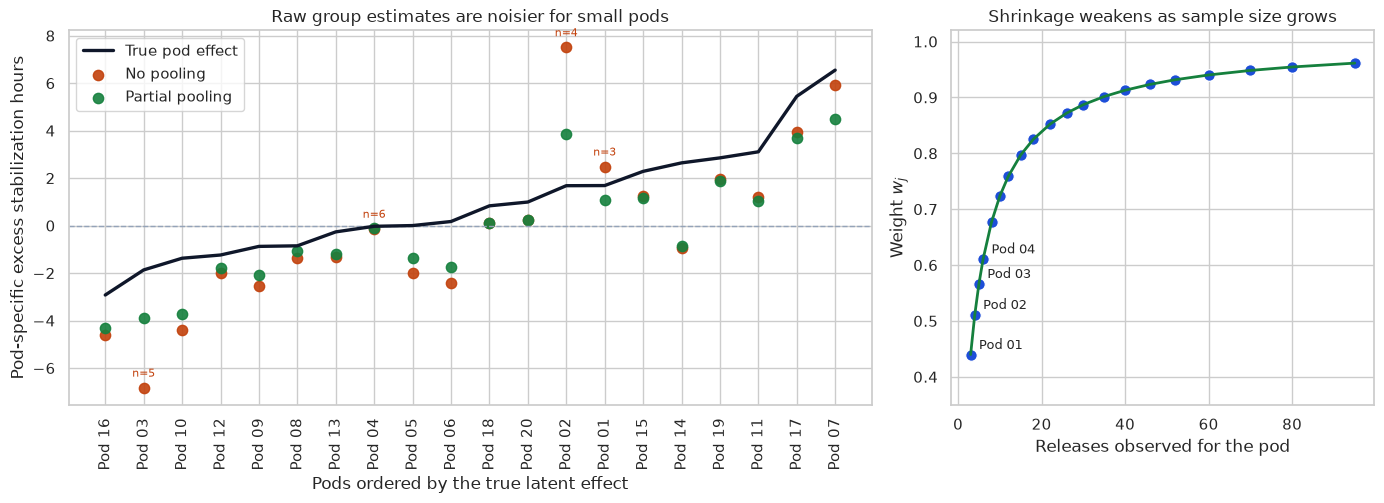

In [5]:
# Show both the effect estimates and the shrinkage mechanism behind them.
ordered = pod_summary.sort_values("true_effect").reset_index(drop=True)
positions = np.arange(len(ordered))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1.9, 1]})

# Left panel: compare raw, shrunk, and true pod effects on the same adjusted scale.
axes[0].axhline(0, color="#94a3b8", linestyle="--", linewidth=1)
axes[0].plot(
    positions,
    ordered["true_effect"],
    color=COLORS["truth"],
    linewidth=2.4,
    label="True pod effect",
)
axes[0].scatter(
    positions,
    ordered["no_pooling"],
    color=COLORS["no_pool"],
    s=55,
    alpha=0.9,
    label="No pooling",
)
axes[0].scatter(
    positions,
    ordered["partial_pooling"],
    color=COLORS["partial"],
    s=55,
    alpha=0.9,
    label="Partial pooling",
)

for _, row in ordered.nsmallest(4, "n_releases").iterrows():
    idx = ordered.index[ordered["pod_id"] == row["pod_id"]][0]
    axes[0].annotate(
        f"n={int(row['n_releases'])}",
        (idx, row["no_pooling"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8,
        color=COLORS["no_pool"],
    )

axes[0].set_title("Raw group estimates are noisier for small pods")
axes[0].set_xlabel("Pods ordered by the true latent effect")
axes[0].set_ylabel("Pod-specific excess stabilization hours")
axes[0].set_xticks(positions)
axes[0].set_xticklabels(ordered["pod_id"], rotation=90)
axes[0].legend(frameon=True, loc="upper left")

# Right panel: plot the empirical-Bayes weight as a function of observed pod volume.
weight_curve = pod_summary.sort_values("n_releases")
axes[1].plot(
    weight_curve["n_releases"],
    weight_curve["partial_pooling_weight"],
    color=COLORS["partial"],
    linewidth=2,
)
axes[1].scatter(
    pod_summary["n_releases"],
    pod_summary["partial_pooling_weight"],
    color=COLORS["accent"],
    s=70,
    edgecolor="white",
    linewidth=0.9,
)

for _, row in pod_summary.nsmallest(4, "n_releases").iterrows():
    axes[1].annotate(
        str(row["pod_id"]),
        (row["n_releases"], row["partial_pooling_weight"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=9,
    )

axes[1].set_ylim(0.35, 1.02)
axes[1].set_title("Shrinkage weakens as sample size grows")
axes[1].set_xlabel("Releases observed for the pod")
axes[1].set_ylabel("Weight $w_j$")

plt.tight_layout()
plt.show()


The comparison above captures the main practical lesson.

- Pods with only 3 to 6 releases can look extreme under no pooling simply because their adjusted residual averages are noisy.
- Partial pooling preserves directional information but tempers those extremes.
- Large pods still keep most of their signal because their shrinkage weights are close to 1.

This is why hierarchical modeling is more than a technical convenience. It changes how confidently we should react to apparent outliers in grouped operational data.

## 6. Decision Consequence: Which Pods Should Receive an Engineering Audit?

Suppose leadership can fund only **four deep-dive audits** next quarter. The goal is to target the pods with the largest true latent stabilization burden, not the pods that merely look bad because of small-sample volatility.

We therefore compare which four pods would be selected by:

- the oracle truth (available only because this is a simulation),
- the no-pooling ranking,
- the partial-pooling ranking.


,strategy,selected_pods,average_true_effect,overlap_with_oracle
0,Oracle truth,"Pod 07, Pod 17, Pod 11, Pod 19",4.488,4
1,No pooling,"Pod 02, Pod 07, Pod 17, Pod 01",3.840,2
2,Partial pooling,"Pod 07, Pod 02, Pod 17, Pod 19",4.132,3


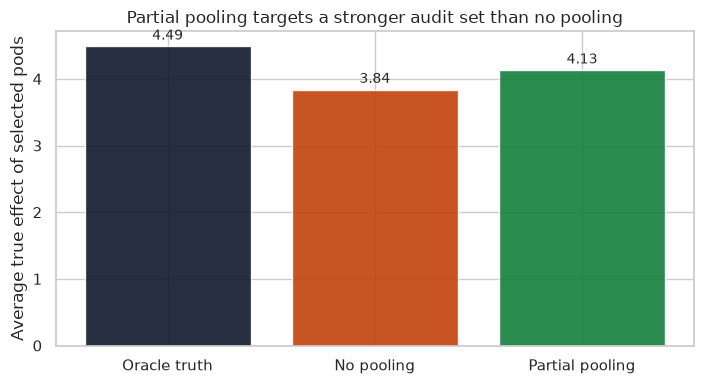

In [6]:
# Compare audit choices implied by oracle truth, raw group means, and partial pooling.
audit_budget = 4


def select_top(frame, column, k):
    """
    Select the highest-risk pods according to one ranking score.

    Parameters:
        frame: Pod-level summary table containing truth, no-pooling, and partial-pooling scores.
        column: Name of the score used to rank pods for the audit decision.
        k: Number of pods that can be selected under the audit budget.

    Returns:
        A copy of the `k` rows with the largest score in `column`, preserving all pod-level diagnostics for later comparison.

    Idea:
        The same operational budget can select different pods depending on whether the ranking score overreacts to small noisy groups.
    """
    return frame.nlargest(k, column).copy()

oracle_selection = select_top(pod_summary, "true_effect", audit_budget)
no_pool_selection = select_top(pod_summary, "no_pooling", audit_budget)
partial_selection = select_top(pod_summary, "partial_pooling", audit_budget)

oracle_pods = set(oracle_selection["pod_id"].astype(str))

# Measure both who is selected and how much true latent burden the selected set captures.
decision_table = pd.DataFrame(
    [
        {
            "strategy": "Oracle truth",
            "selected_pods": ", ".join(oracle_selection["pod_id"].astype(str)),
            "average_true_effect": oracle_selection["true_effect"].mean(),
            "overlap_with_oracle": audit_budget,
        },
        {
            "strategy": "No pooling",
            "selected_pods": ", ".join(no_pool_selection["pod_id"].astype(str)),
            "average_true_effect": no_pool_selection["true_effect"].mean(),
            "overlap_with_oracle": len(set(no_pool_selection["pod_id"].astype(str)) & oracle_pods),
        },
        {
            "strategy": "Partial pooling",
            "selected_pods": ", ".join(partial_selection["pod_id"].astype(str)),
            "average_true_effect": partial_selection["true_effect"].mean(),
            "overlap_with_oracle": len(set(partial_selection["pod_id"].astype(str)) & oracle_pods),
        },
    ]
)

display(decision_table.round(3))

fig, ax = plt.subplots(figsize=(7.2, 4))
bars = ax.bar(
    decision_table["strategy"],
    decision_table["average_true_effect"],
    color=[COLORS["truth"], COLORS["no_pool"], COLORS["partial"]],
    alpha=0.9,
)

ax.set_ylabel("Average true effect of selected pods")
ax.set_title("Partial pooling targets a stronger audit set than no pooling")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()


In this run, no pooling spends too much attention on one tiny pod that looks unusually bad because of noise. Partial pooling remains imperfect. It allocates scarce auditing capacity more sensibly by discounting the most extreme small-sample estimates.

That is the decision-science value of hierarchical inference: it reduces the chance that limited interventions are driven by sampling luck.

## 7. Reading the Variance Components and Fixed Effects

Hierarchical models do two jobs at once:

1. estimate the common effects of observed covariates,
2. estimate how much unexplained variation remains at the group level.

The group-level variance $\tau^2$ tells us whether pods really differ after adjustment. The intraclass correlation

$$
\text{ICC} = \frac{\tau^2}{\tau^2 + \sigma^2}
$$

gives the share of unexplained variance attributable to between-pod heterogeneity under the random-intercept specification.


In [7]:
# Summarize fixed effects and variance components from the pooled and hierarchical fits.
coefficient_comparison = pd.DataFrame(
    {
        "term": ["Intercept", "Severity", "Queue load", "Enterprise", "Weekend"],
        "pooled_ols": [
            complete_pooling.params["Intercept"],
            complete_pooling.params["severity"],
            complete_pooling.params["queue_load"],
            complete_pooling.params["enterprise"],
            complete_pooling.params["weekend"],
        ],
        "hierarchical_fixed_effect": [
            hierarchical_model.fe_params["Intercept"],
            hierarchical_model.fe_params["severity"],
            hierarchical_model.fe_params["queue_load"],
            hierarchical_model.fe_params["enterprise"],
            hierarchical_model.fe_params["weekend"],
        ],
        "data_generating_value": [14.0, 1.8, 4.2, 2.6, 1.3],
    }
)

# The variance table separates persistent pod heterogeneity from release-level noise.
variance_components = pd.DataFrame(
    [
        {"quantity": "Between-pod variance tau^2", "value": tau2},
        {"quantity": "Within-pod variance sigma^2", "value": sigma2},
        {"quantity": "Intraclass correlation (ICC)", "value": tau2 / (tau2 + sigma2)},
    ]
)

display(coefficient_comparison.round(3))
display(variance_components.round(3))


,term,pooled_ols,hierarchical_fixed_effect,data_generating_value
0,Intercept,12.136,12.412,14.0
1,Severity,1.984,1.903,1.8
2,Queue load,6.498,6.287,4.2
3,Enterprise,3.471,3.512,2.6
4,Weekend,1.485,1.411,1.3


,quantity,value
0,Between-pod variance tau^2,7.816
1,Within-pod variance sigma^2,29.859
2,Intraclass correlation (ICC),0.207


The fixed-effect estimates remain close to the data-generating values, but the key hierarchical output is the variance decomposition. Here the within-pod variance is larger than the between-pod variance, so individual releases remain noisy even after adjusting for severity, queue load, enterprise status, and weekend timing. The ICC is still meaningfully above zero, which means pod identity explains a nontrivial share of residual variation. That is enough structure to justify partial pooling and avoid treating every pod mean as equally reliable.

<!-- real-data-companion-course01 -->
## Real-Data Companion: Partial Pooling Intuition with Grunfeld Firms

The Grunfeld panel has repeated observations for firms with very different investment scales. That makes it useful for partial-pooling intuition because the analyst can see both within-firm repetition and persistent between-firm differences.

The unit is a firm-year observation, and the outcome is investment. Firms differ in their typical investment levels, market values, and capital stocks. A no-pooling estimate treats each firm mean as independent, complete pooling ignores firm identity, and partial pooling sits between those extremes by borrowing strength across related groups.

The companion is an empirical-Bayes style illustration, with a full hierarchical model left for a deeper extension. Its main lesson is that pooling strength depends on group sample size, within-group noise, and between-group variation. Real panel data make those tradeoffs more concrete than a purely synthetic example.

For clarity, the unit is a firm-year record. The outcome is investment, and the experiment compares no-pooling, complete-pooling, and partial-pooling summaries. The grouped dataset is what makes shrinkage and borrowing strength visible.

Data source: [Grunfeld investment data in statsmodels](https://www.statsmodels.org/stable/datasets/generated/grunfeld.html).

,firm,n,no_pooling_mean,within_sd,shrinkage_weight,partial_pooling_mean,complete_pooling_mean
5,General Motors,20,608.02,309.57,0.99,601.29,133.31
8,US Steel,20,410.48,125.40,0.99,406.55,133.31
4,General Electric,20,102.29,48.58,0.99,102.73,133.31
2,Chrysler,20,86.12,42.73,0.99,86.79,133.31
1,Atlantic Refining,20,61.80,15.17,0.99,62.82,133.31
7,IBM,20,55.41,34.95,0.99,56.52,133.31
9,Union Oil,20,47.60,18.32,0.99,48.81,133.31
10,Westinghouse,20,42.89,19.11,0.99,44.17,133.31
6,Goodyear,20,41.89,14.88,0.99,43.19,133.31
0,American Steel,20,6.85,3.20,0.99,8.64,133.31


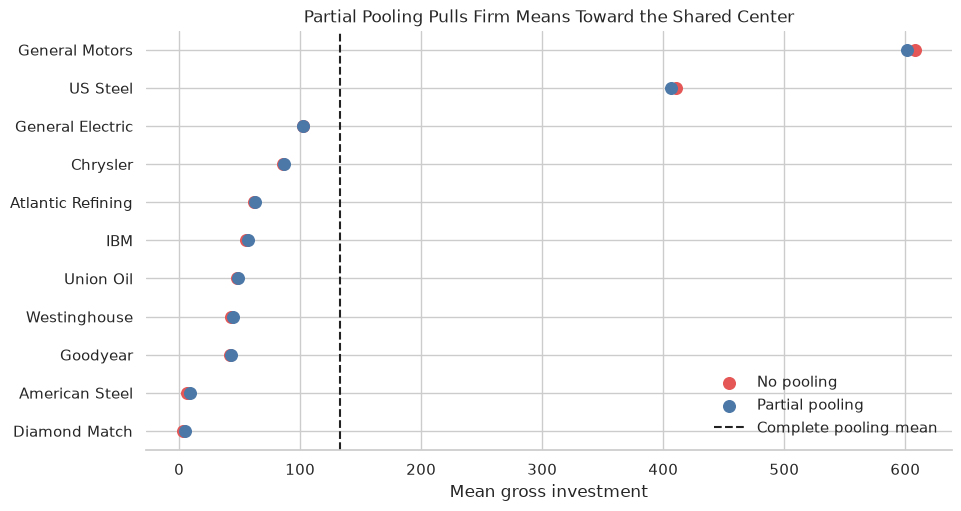

In [8]:
# real-data-companion-course01
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def _find_project_root(start=Path.cwd()):
    """
    Find the nearest project root that exposes shared notebook helpers.

    Parameters:
        start: Directory from which the upward search begins, usually the current notebook working directory.

    Returns:
        The closest parent path containing `notebooks/_shared`; returns `start` when the helper directory is unavailable.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display
from notebooks._shared.real_data import load_statsmodels_grunfeld, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    grunfeld = load_statsmodels_grunfeld().copy()

    # Treat each firm's mean investment as the noisy group estimate to be shrunk.
    global_mean = grunfeld["invest"].mean()
    within_var = grunfeld.groupby("firm")["invest"].var().mean()
    between_var = grunfeld.groupby("firm")["invest"].mean().var()

    firm_summary = (
        grunfeld.groupby("firm")
        .agg(n=("invest", "size"), no_pooling_mean=("invest", "mean"), within_sd=("invest", "std"))
        .reset_index()
    )
    firm_summary["shrinkage_weight"] = between_var / (between_var + within_var / firm_summary["n"])
    firm_summary["partial_pooling_mean"] = (
        firm_summary["shrinkage_weight"] * firm_summary["no_pooling_mean"]
        + (1 - firm_summary["shrinkage_weight"]) * global_mean
    )
    firm_summary["complete_pooling_mean"] = global_mean
    smart_display(firm_summary.sort_values("no_pooling_mean", ascending=False).round(2))

    fig, ax = plt.subplots(figsize=(9.5, 5), constrained_layout=True)
    ordered = firm_summary.sort_values("no_pooling_mean")
    ax.scatter(ordered["no_pooling_mean"], ordered["firm"], label="No pooling", color="#E45756", s=70)
    ax.scatter(ordered["partial_pooling_mean"], ordered["firm"], label="Partial pooling", color="#4C78A8", s=70)
    ax.axvline(global_mean, color="#222222", linestyle="--", linewidth=1.5, label="Complete pooling mean")
    ax.set_title("Partial Pooling Pulls Firm Means Toward the Shared Center")
    ax.set_xlabel("Mean gross investment")
    ax.set_ylabel("")
    ax.legend(frameon=False)
    sns.despine(fig=fig, left=True)
    plt.show()
else:
    optional_data_note(
        "Grunfeld Investment Data",
        "https://www.statsmodels.org/stable/datasets/generated/grunfeld.html",
        "RUN_REAL_DATA_COMPANION",
    )


<!-- real-data-companion-course01 -->
This is an empirical-Bayes style illustration, not a full hierarchical model fit. The Grunfeld firms all have the same number of observations, and their average investment levels differ sharply, so the estimated shrinkage weights are close to one. That outcome is itself useful: partial pooling is strongest when group evidence is weak relative to the common distribution, and mild when persistent between-group differences dominate. The figure shows the common-center logic without implying that every grouped dataset should shrink heavily.

## What to Remember

- Complete pooling is too blunt when persistent group differences matter.
- No pooling is too volatile when some groups are small.
- Partial pooling combines local information with global regularization.
- The shrinkage weight depends on both signal strength ($\tau^2$) and effective sample size ($n_j$).
- Hierarchical models are especially valuable when decisions depend on ranking groups for scarce interventions.

In practice, the next step would be to extend the analysis to random slopes, crossed effects, or hierarchical generalized linear models when the outcome is binary or count-valued.


## References

- Efron, B., & Morris, C. N. (1975). *Data analysis using Stein's estimator and its generalizations.* *Journal of the American Statistical Association, 70*(350), 311-319. [https://doi.org/10.1080/01621459.1975.10479864](https://doi.org/10.1080/01621459.1975.10479864)
- Gelman, A., & Pardoe, I. (2006). *Bayesian measures of explained variance and pooling in multilevel (hierarchical) models.* *Technometrics, 48*(2), 241-251. [https://doi.org/10.1198/004017005000000517](https://doi.org/10.1198/004017005000000517)
- Laird, N. M., & Ware, J. H. (1982). *Random-effects models for longitudinal data.* *Biometrics, 38*(4), 963-974. [https://doi.org/10.2307/2529876](https://doi.org/10.2307/2529876)
